In [2]:
!pip install opencv-python numpy pandas tqdm pycryptodome


   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   --- ------------------------------------ 3.4/39.0 MB 18.9 MB/s eta 0:00:02
   --------- ------------------------------ 8.9/39.0 MB 22.3 MB/s eta 0:00:02
   -------------- ------------------------- 13.9/39.0 MB 22.7 MB/s eta 0:00:02
   ------------------ --------------------- 17.8/39.0 MB 21.6 MB/s eta 0:00:01
   ---------------------- ----------------- 22.3/39.0 MB 21.5 MB/s eta 0:00:01
   ------------------------------ --------- 29.9/39.0 MB 24.0 MB/s eta 0:00:01
   -------------------------------------- - 38.0/39.0 MB 26.2 MB/s eta 0:00:01
   ---------------------------------------- 39.0/39.0 MB 25.2 MB/s eta 0:00:00


In [3]:
import cv2
print("OpenCV version:", cv2.__version__)


OpenCV version: 4.12.0


In [14]:
from PIL import Image
import os

folder_path = r"C:\\Class Projects\\Important\\NTCC_Final_Semester\\JNU intership\\textures\\textures"

print("Image Resolutions:\n")

resolutions = {}

for filename in os.listdir(folder_path):
    file_path = os.path.join(folder_path, filename)

    try:
        with Image.open(file_path) as img:
            width, height = img.size
            print(f"{filename:25s} -> {width} x {height}")

            # Store resolution count
            resolutions[(width, height)] = resolutions.get((width, height), 0) + 1

    except Exception as e:
        print(f"{filename:25s} -> Not an image / Error")

print("\nSummary:")
for res, count in resolutions.items():
    print(f"{res[0]} x {res[1]} : {count} images")

Image Resolutions:

1.1.01.tiff               -> 512 x 512
1.1.02.tiff               -> 512 x 512
1.1.03.tiff               -> 512 x 512
1.1.04.tiff               -> 512 x 512
1.1.05.tiff               -> 512 x 512
1.1.06.tiff               -> 512 x 512
1.1.07.tiff               -> 512 x 512
1.1.08.tiff               -> 512 x 512
1.1.09.tiff               -> 512 x 512
1.1.10.tiff               -> 512 x 512
1.1.11.tiff               -> 512 x 512
1.1.12.tiff               -> 512 x 512
1.1.13.tiff               -> 512 x 512
1.2.01.tiff               -> 512 x 512
1.2.02.tiff               -> 512 x 512
1.2.03.tiff               -> 512 x 512
1.2.04.tiff               -> 512 x 512
1.2.05.tiff               -> 512 x 512
1.2.06.tiff               -> 512 x 512
1.2.07.tiff               -> 512 x 512
1.2.08.tiff               -> 512 x 512
1.2.09.tiff               -> 512 x 512
1.2.10.tiff               -> 512 x 512
1.2.11.tiff               -> 512 x 512
1.2.12.tiff               -> 512 x 512
1.2.1

In [15]:
from PIL import Image
import os
import shutil

# -------- Paths --------
input_folder = r"C:\\Class Projects\\Important\\NTCC_Final_Semester\\JNU intership\\textures\\textures"
output_base  = r"C:\\Class Projects\\Important\\NTCC_Final_Semester\\JNU intership\\aerials\\by_resolution"
# Create base output folder
os.makedirs(output_base, exist_ok=True)

print("Separating textures images by resolution...\n")

for filename in os.listdir(input_folder):
    src_path = os.path.join(input_folder, filename)

    try:
        with Image.open(src_path) as img:
            w, h = img.size
            folder_name = f"{w}x{h}"

        # Create resolution folder
        dest_folder = os.path.join(output_base, folder_name)
        os.makedirs(dest_folder, exist_ok=True)

        # Copy file
        dest_path = os.path.join(dest_folder, filename)
        shutil.copy2(src_path, dest_path)

        print(f"{filename:25s} → {folder_name}")

    except Exception:
        print(f"{filename:25s} → Skipped (not an image / unreadable)")

print("\n✅ Done! Check:", output_base)


Separating textures images by resolution...

1.1.01.tiff               → 512x512
1.1.02.tiff               → 512x512
1.1.03.tiff               → 512x512
1.1.04.tiff               → 512x512
1.1.05.tiff               → 512x512
1.1.06.tiff               → 512x512
1.1.07.tiff               → 512x512
1.1.08.tiff               → 512x512
1.1.09.tiff               → 512x512
1.1.10.tiff               → 512x512
1.1.11.tiff               → 512x512
1.1.12.tiff               → 512x512
1.1.13.tiff               → 512x512
1.2.01.tiff               → 512x512
1.2.02.tiff               → 512x512
1.2.03.tiff               → 512x512
1.2.04.tiff               → 512x512
1.2.05.tiff               → 512x512
1.2.06.tiff               → 512x512
1.2.07.tiff               → 512x512
1.2.08.tiff               → 512x512
1.2.09.tiff               → 512x512
1.2.10.tiff               → 512x512
1.2.11.tiff               → 512x512
1.2.12.tiff               → 512x512
1.2.13.tiff               → 512x512
1.3.01.tiff        

In [2]:
import cv2
import numpy as np
import os
import pandas as pd
from scipy.stats import entropy
from Crypto.Cipher import AES
from Crypto.Util.Padding import pad, unpad
from Crypto.Random import get_random_bytes

# --- PATH CONFIGURATIONS ---
INPUT_DIR = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\aerials\by_resolution\512x512"
ENC_FOLDER = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\AES_512\Encrypted22"
DEC_FOLDER = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\AES_512\Decrypted22"
EXCEL_OUTPUT = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\AES_Evaluation_512_22.xlsx"

# Ensure folders exist
for folder in [ENC_FOLDER, DEC_FOLDER]:
    os.makedirs(folder, exist_ok=True)

# AES Key (16 bytes for AES-128)
KEY = get_random_bytes(16)

def get_correlation(img_array):
    """Calculates Horizontal, Vertical, and Diagonal correlation of a 2D array."""
    h, w = img_array.shape
    n = 3000  # Number of random pixel pairs
    x = np.random.randint(0, h - 1, n)
    y = np.random.randint(0, w - 1, n)

    # Convert to float to prevent 8-bit overflow during calculation
    img_float = img_array.astype(np.float32)

    corr_h = np.corrcoef(img_float[x, y], img_float[x, y + 1])[0, 1]
    corr_v = np.corrcoef(img_float[x, y], img_float[x + 1, y])[0, 1]
    corr_d = np.corrcoef(img_float[x, y], img_float[x + 1, y + 1])[0, 1]
    return corr_h, corr_v, corr_d

def calculate_npcr_uaci(c1_array, c2_array):
    """Calculates NPCR and UACI between two ciphertext images."""
    # Convert to float to prevent underflow/overflow when subtracting uint8 values
    c1_float = c1_array.astype(np.float64)
    c2_float = c2_array.astype(np.float64)
    
    # NPCR
    diff = np.where(c1_array != c2_array, 1, 0)
    npcr = (np.sum(diff) / diff.size) * 100
    
    # UACI
    uaci = (np.sum(np.abs(c1_float - c2_float)) / (diff.size * 255)) * 100
    return npcr, uaci
# --- EXECUTION ---
files = [f for f in os.listdir(INPUT_DIR) if f.lower().endswith(('.png', '.jpg', '.tif', '.tiff', '.bmp'))]
all_metrics = []

if not files:
    print(f"Error: No images found in {INPUT_DIR}")
else:
    print(f"Processing {len(files)} images...")

for filename in files:
    orig_path = os.path.join(INPUT_DIR, filename)
    img = cv2.imread(orig_path)
    
    if img is not None:
        gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        h, w = gray_img.shape

        # ==========================================
        # 1. ENCRYPT ORIGINAL IMAGE (C1)
        # ==========================================
        cipher1_enc = AES.new(KEY, AES.MODE_CBC)
        iv = cipher1_enc.iv  # Save IV to use for decryption AND for C2
        
        enc_bytes_1 = cipher1_enc.encrypt(pad(gray_img.tobytes(), AES.block_size))
        
        # Reshape encrypted bytes for saving and metrics (omitting padding)
        c1_array = np.frombuffer(enc_bytes_1[:gray_img.size], dtype=np.uint8).reshape((h, w))
        cv2.imwrite(os.path.join(ENC_FOLDER, filename), c1_array)

if not files:
    print(f"Error: No images found in {INPUT_DIR}")
else:
    print(f"Processing {len(files)} images...")

for filename in files:
    orig_path = os.path.join(INPUT_DIR, filename)
    img = cv2.imread(orig_path)
    
    if img is not None:
        gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        h, w = gray_img.shape

        # ==========================================
        # 1. ENCRYPT ORIGINAL IMAGE (C1)
        # ==========================================
        cipher1_enc = AES.new(KEY, AES.MODE_CBC)
        iv = cipher1_enc.iv  # Save IV to use for decryption AND for C2
        
        enc_bytes_1 = cipher1_enc.encrypt(pad(gray_img.tobytes(), AES.block_size))
        
        # Reshape encrypted bytes for saving and metrics (omitting padding)
        c1_array = np.frombuffer(enc_bytes_1[:gray_img.size], dtype=np.uint8).reshape((h, w))
        cv2.imwrite(os.path.join(ENC_FOLDER, filename), c1_array)
        
        all_metrics.append({
            "Filename": filename,
            "Entropy": ent, 
            "Corr_H": corr_h, 
            "Corr_V": corr_v, 
            "Corr_D": corr_d, 
            "NPCR_%": npcr, 
            "UACI_%": uaci
        })

        # ==========================================
        # 4. DECRYPT ORIGINAL IMAGE
        # ==========================================
        # Decrypt using the full enc_bytes_1 (which still includes the padding)
        cipher_dec = AES.new(KEY, AES.MODE_CBC, iv=iv)
        decrypted_bytes = unpad(cipher_dec.decrypt(enc_bytes_1), AES.block_size)
        
        dec_img_array = np.frombuffer(decrypted_bytes, dtype=np.uint8).reshape((h, w))
        cv2.imwrite(os.path.join(DEC_FOLDER, filename), dec_img_array)
        
        print(f"Done: {filename}")
# --- DATA EXPORT ---
if all_metrics:
    df = pd.DataFrame(all_metrics)
    
    # Select only numeric columns to avoid errors when calculating the mean
    numeric_df = df.select_dtypes(include=[np.number])
    avg_stats = numeric_df.mean()

    with pd.ExcelWriter(EXCEL_OUTPUT) as writer:
        df.to_excel(writer, sheet_name='Per_Image_Metrics', index=False)
        avg_stats.to_frame(name='Average_Value').to_excel(writer, sheet_name='Dataset_Averages')

    print("\n" + "="*40)
    print("AVERAGE STATS ACROSS DATASET")
    print("="*40)
    print(avg_stats.to_string())
    print(f"\nExcel report generated: {EXCEL_OUTPUT}")


Processing 73 images...
Done: 1.1.01.tiff
Done: 1.1.02.tiff
Done: 1.1.03.tiff
Done: 1.1.04.tiff
Done: 1.1.05.tiff
Done: 1.1.06.tiff
Done: 1.1.07.tiff
Done: 1.1.08.tiff
Done: 1.1.09.tiff
Done: 1.1.10.tiff
Done: 1.1.11.tiff
Done: 1.1.12.tiff
Done: 1.1.13.tiff
Done: 1.2.01.tiff
Done: 1.2.02.tiff
Done: 1.2.03.tiff
Done: 1.2.04.tiff
Done: 1.2.05.tiff
Done: 1.2.06.tiff
Done: 1.2.07.tiff
Done: 1.2.08.tiff
Done: 1.2.09.tiff
Done: 1.2.10.tiff
Done: 1.2.11.tiff
Done: 1.2.12.tiff
Done: 1.2.13.tiff
Done: 1.5.01.tiff
Done: 1.5.02.tiff
Done: 1.5.03.tiff
Done: 1.5.04.tiff
Done: 1.5.05.tiff
Done: 1.5.06.tiff
Done: 1.5.07.tiff
Done: 2.1.01.tiff
Done: 2.1.02.tiff
Done: 2.1.03.tiff
Done: 2.1.04.tiff
Done: 2.1.05.tiff
Done: 2.1.06.tiff
Done: 2.1.07.tiff
Done: 2.1.08.tiff
Done: 2.1.09.tiff
Done: 2.1.10.tiff
Done: 2.1.11.tiff
Done: 2.1.12.tiff
Done: 4.2.01.tiff
Done: 4.2.03.tiff
Done: 4.2.05.tiff
Done: 4.2.06.tiff
Done: 4.2.07.tiff
Done: 5.2.08.tiff
Done: 5.2.09.tiff
Done: 5.2.10.tiff
Done: 7.1.01.tiff
Done

In [1]:
import cv2
import numpy as np
import os
import pandas as pd
from scipy.stats import entropy
from Crypto.Cipher import AES
from Crypto.Util.Padding import pad, unpad
from Crypto.Random import get_random_bytes

# --- PATH CONFIGURATIONS ---
INPUT_DIR = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\aerials\by_resolution\1024x1024"
ENC_FOLDER = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\AES_1024\Encrypted22"
DEC_FOLDER = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\AES_1024\Decrypted22"
EXCEL_OUTPUT = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\AES_Evaluation_1024_22.xlsx"

# Ensure folders exist
for folder in [ENC_FOLDER, DEC_FOLDER]:
    os.makedirs(folder, exist_ok=True)

# AES Key (16 bytes for AES-128)
KEY = get_random_bytes(16)

def get_correlation(img_array):
    """Calculates Horizontal, Vertical, and Diagonal correlation of a 2D array."""
    h, w = img_array.shape
    n = 3000  # Number of random pixel pairs
    x = np.random.randint(0, h - 1, n)
    y = np.random.randint(0, w - 1, n)

    # Convert to float to prevent 8-bit overflow during calculation
    img_float = img_array.astype(np.float32)

    corr_h = np.corrcoef(img_float[x, y], img_float[x, y + 1])[0, 1]
    corr_v = np.corrcoef(img_float[x, y], img_float[x + 1, y])[0, 1]
    corr_d = np.corrcoef(img_float[x, y], img_float[x + 1, y + 1])[0, 1]
    return corr_h, corr_v, corr_d

def calculate_npcr_uaci(c1_array, c2_array):
    """Calculates NPCR and UACI between two ciphertext images."""
    # Convert to float to prevent underflow/overflow when subtracting uint8 values
    c1_float = c1_array.astype(np.float64)
    c2_float = c2_array.astype(np.float64)
    
    # NPCR
    diff = np.where(c1_array != c2_array, 1, 0)
    npcr = (np.sum(diff) / diff.size) * 100
    
    # UACI
    uaci = (np.sum(np.abs(c1_float - c2_float)) / (diff.size * 255)) * 100
    return npcr, uaci

# --- EXECUTION ---
files = [f for f in os.listdir(INPUT_DIR) if f.lower().endswith(('.png', '.jpg', '.tif', '.tiff', '.bmp'))]
all_metrics = []

if not files:
    print(f"Error: No images found in {INPUT_DIR}")
else:
    print(f"Processing {len(files)} images...")

for filename in files:
    orig_path = os.path.join(INPUT_DIR, filename)
    img = cv2.imread(orig_path)
    
    if img is not None:
        gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        h, w = gray_img.shape

        # ==========================================
        # 1. ENCRYPT ORIGINAL IMAGE (C1)
        # ==========================================
        cipher1_enc = AES.new(KEY, AES.MODE_CBC)
        iv = cipher1_enc.iv  # Save IV to use for decryption AND for C2
        
        enc_bytes_1 = cipher1_enc.encrypt(pad(gray_img.tobytes(), AES.block_size))
        
        # Reshape encrypted bytes for saving and metrics (omitting padding)
        c1_array = np.frombuffer(enc_bytes_1[:gray_img.size], dtype=np.uint8).reshape((h, w))
        cv2.imwrite(os.path.join(ENC_FOLDER, filename), c1_array)

        # ==========================================
        # 2. ENCRYPT MODIFIED IMAGE (C2)
        # ==========================================
        # Copy original image and change exactly ONE pixel for differential analysis
        gray_img_mod = gray_img.copy()
        gray_img_mod[0, 0] ^= 1
        
        # Encrypt modified image using the SAME Key and SAME IV
        cipher2_enc = AES.new(KEY, AES.MODE_CBC, iv=iv)
        enc_bytes_2 = cipher2_enc.encrypt(pad(gray_img_mod.tobytes(), AES.block_size))
        c2_array = np.frombuffer(enc_bytes_2[:gray_img_mod.size], dtype=np.uint8).reshape((h, w))

        # ==========================================
        # 3. CALCULATE METRICS
        # ==========================================
        # Global Shannon Entropy (on C1)
        hist, _ = np.histogram(c1_array, bins=256, range=(0, 256))
        prob = hist / hist.sum()
        ent = entropy(prob + 1e-9, base=2)
        
        # Correlation Coefficients (on C1)
        corr_h, corr_v, corr_d = get_correlation(c1_array)
        
        # NPCR and UACI (comparing C1 and C2)
        npcr, uaci = calculate_npcr_uaci(c1_array, c2_array)
        
        all_metrics.append({
            "Filename": filename,
            "Entropy": ent, 
            "Corr_H": corr_h, 
            "Corr_V": corr_v, 
            "Corr_D": corr_d, 
            "NPCR_%": npcr, 
            "UACI_%": uaci
        })

        # ==========================================
        # 4. DECRYPT ORIGINAL IMAGE
        # ==========================================
        # Decrypt using the full enc_bytes_1 (which still includes the padding)
        cipher_dec = AES.new(KEY, AES.MODE_CBC, iv=iv)
        decrypted_bytes = unpad(cipher_dec.decrypt(enc_bytes_1), AES.block_size)
        
        dec_img_array = np.frombuffer(decrypted_bytes, dtype=np.uint8).reshape((h, w))
        cv2.imwrite(os.path.join(DEC_FOLDER, filename), dec_img_array)
        
        print(f"Done: {filename}")

# --- DATA EXPORT ---
if all_metrics:
    df = pd.DataFrame(all_metrics)
    
    # Select only numeric columns to avoid errors when calculating the mean
    numeric_df = df.select_dtypes(include=[np.number])
    avg_stats = numeric_df.mean()

    with pd.ExcelWriter(EXCEL_OUTPUT) as writer:
        df.to_excel(writer, sheet_name='Per_Image_Metrics', index=False)
        avg_stats.to_frame(name='Average_Value').to_excel(writer, sheet_name='Dataset_Averages')

    print("\n" + "="*40)
    print("AVERAGE STATS ACROSS DATASET")
    print("="*40)
    print(avg_stats.to_string())
    print(f"\nExcel report generated: {EXCEL_OUTPUT}")

Processing 53 images...
Done: 1.3.01.tiff
Done: 1.3.02.tiff
Done: 1.3.03.tiff
Done: 1.3.04.tiff
Done: 1.3.05.tiff
Done: 1.3.06.tiff
Done: 1.3.07.tiff
Done: 1.3.08.tiff
Done: 1.3.09.tiff
Done: 1.3.10.tiff
Done: 1.3.11.tiff
Done: 1.3.12.tiff
Done: 1.3.13.tiff
Done: 1.4.01.tiff
Done: 1.4.02.tiff
Done: 1.4.03.tiff
Done: 1.4.04.tiff
Done: 1.4.05.tiff
Done: 1.4.06.tiff
Done: 1.4.07.tiff
Done: 1.4.08.tiff
Done: 1.4.09.tiff
Done: 1.4.10.tiff
Done: 1.4.11.tiff
Done: 1.4.12.tiff
Done: 2.2.01.tiff
Done: 2.2.02.tiff
Done: 2.2.03.tiff
Done: 2.2.04.tiff
Done: 2.2.05.tiff
Done: 2.2.06.tiff
Done: 2.2.07.tiff
Done: 2.2.08.tiff
Done: 2.2.09.tiff
Done: 2.2.10.tiff
Done: 2.2.11.tiff
Done: 2.2.12.tiff
Done: 2.2.13.tiff
Done: 2.2.14.tiff
Done: 2.2.15.tiff
Done: 2.2.16.tiff
Done: 2.2.17.tiff
Done: 2.2.18.tiff
Done: 2.2.19.tiff
Done: 2.2.20.tiff
Done: 2.2.21.tiff
Done: 2.2.22.tiff
Done: 2.2.23.tiff
Done: 2.2.24.tiff
Done: 3.2.25.tiff
Done: 5.3.01.tiff
Done: 5.3.02.tiff
Done: 7.2.01.tiff

AVERAGE STATS ACROSS 

In [1]:
import numpy as np
from PIL import Image
import os
import pandas as pd

# --- Configuration ---
INPUT_DIR = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\aerials\by_resolution\512x512"
ENC_FOLDER = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\chaos_enc_512"
EXCEL_OUTPUT = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\chaos_encryption_512.xlsx"

os.makedirs(ENC_FOLDER, exist_ok=True)

# --- 1. Chaos & Encryption Functions ---

def logistic_map(x0, r, size):
    """Generates a high-precision chaotic sequence."""
    x = x0
    # Warm-up to reach chaotic state
    for _ in range(300):
        x = r * x * (1 - x)
    
    sequence = np.zeros(size)
    for i in range(size):
        x = r * x * (1 - x)
        sequence[i] = x
    return sequence

def encrypt_image(img_arr, x0_base, r):
    rows, cols = img_arr.shape
    size = rows * cols
    
    # --- STEP 1: Image-Dependent Key ---
    img_sum = np.sum(img_arr.astype(np.float64))
    x0_dynamic = (x0_base + (img_sum / 10**13)) % 1.0
    
    # --- STEP 2: Generate Chaos ---
    chaos_seq = logistic_map(x0_dynamic, r, size * 2)
    
    # Use first half for Permutation (Shuffling)
    # Use second half for Substitution (XOR)
    k_perm = chaos_seq[:size]
    k_sub = (np.floor(np.mod(chaos_seq[size:] * 10**14, 256))).astype(np.uint8)
    
    # --- STEP 3: Permutation (Scrambling) ---
    p_flat = img_arr.flatten()
    idx = np.argsort(k_perm)
    p_scrambled = p_flat[idx]
    
    # --- STEP 4: Substitution (XOR) ---
    c_flat = p_scrambled ^ k_sub
    
    return c_flat.reshape(rows, cols)

# --- 2. Evaluation Metrics ---

def calculate_npcr_uaci(c1, c2):
    c1, c2 = c1.astype(np.float64), c2.astype(np.float64)
    diff = np.where(c1 != c2, 1, 0)
    npcr = (np.sum(diff) / c1.size) * 100
    uaci = (np.sum(np.abs(c1 - c2)) / (255 * c1.size)) * 100
    return npcr, uaci

def calculate_entropy(enc_arr):
    hist, _ = np.histogram(enc_arr, bins=256, range=(0, 256))
    prob = hist / (np.sum(hist) + 1e-10)
    return -np.sum(prob * np.log2(prob + 1e-10))

# --- 3. Execution ---

if __name__ == '__main__':
    x0_base = 0.34567891234567  # Standard initial key
    r_param = 3.999999          # Control parameter (Chaotic regime)
    
    results_list = []
    image_files = [f for f in os.listdir(INPUT_DIR) if f.lower().endswith(('.png', '.jpg', '.tiff', '.tif'))]

    print(f"Starting analysis on {len(image_files)} images...")

    for filename in image_files:
        try:
            img_path = os.path.join(INPUT_DIR, filename)
            p1 = np.array(Image.open(img_path).convert('L'))
            
            # --- NPCR/UACI Test Procedure ---
            # 1. Encrypt original (P1 -> C1)
            c1 = encrypt_image(p1, x0_base, r_param)
            
            # 2. Create P2 (Change exactly ONE pixel)
            p2 = p1.copy()
            p2[0, 0] = (int(p2[0, 0]) + 1) % 256
            
            # 3. Encrypt modified (P2 -> C2)
            # Because of the dynamic x0, C2 will be totally different from C1
            c2 = encrypt_image(p2, x0_base, r_param)
            
            # Save Encrypted Image
            Image.fromarray(c1).save(os.path.join(ENC_FOLDER, f"enc_{filename}"))
            
            # Calculate Metrics
            npcr, uaci = calculate_npcr_uaci(c1, c2)
            entropy = calculate_entropy(c1)
            
            results_list.append({
                "Image Name": filename,
                "NPCR (%)": round(npcr, 5),
                "UACI (%)": round(uaci, 5),
                "Entropy": round(entropy, 5)
            })
            print(f"Processed: {filename} | NPCR: {npcr:.4f}% | UACI: {uaci:.4f}%")
        except Exception as e:
            print(f"Error {filename}: {e}")

    # --- Export Results ---
    if results_list:
        df = pd.DataFrame(results_list)
        avg_row = pd.DataFrame([{
            "Image Name": "AVERAGE STATISTICS",
            "NPCR (%)": df["NPCR (%)"].mean(),
            "UACI (%)": df["UACI (%)"].mean(),
            "Entropy": df["Entropy"].mean()
        }])
        df = pd.concat([df, avg_row], ignore_index=True)
        df.to_excel(EXCEL_OUTPUT, index=False)
        print(f"\nDone! Results saved to: {EXCEL_OUTPUT}")

Starting analysis on 73 images...
Processed: 1.1.01.tiff | NPCR: 99.6037% | UACI: 33.4522%
Processed: 1.1.02.tiff | NPCR: 99.5991% | UACI: 33.5006%
Processed: 1.1.03.tiff | NPCR: 99.6063% | UACI: 33.4539%
Processed: 1.1.04.tiff | NPCR: 99.6231% | UACI: 33.5640%
Processed: 1.1.05.tiff | NPCR: 99.6140% | UACI: 33.5079%
Processed: 1.1.06.tiff | NPCR: 99.6056% | UACI: 33.4352%
Processed: 1.1.07.tiff | NPCR: 99.6044% | UACI: 33.4943%
Processed: 1.1.08.tiff | NPCR: 99.5838% | UACI: 33.4792%
Processed: 1.1.09.tiff | NPCR: 99.6117% | UACI: 33.4090%
Processed: 1.1.10.tiff | NPCR: 99.6120% | UACI: 33.4860%
Processed: 1.1.11.tiff | NPCR: 99.6101% | UACI: 33.4859%
Processed: 1.1.12.tiff | NPCR: 99.6136% | UACI: 33.5041%
Processed: 1.1.13.tiff | NPCR: 99.6220% | UACI: 33.6046%
Processed: 1.2.01.tiff | NPCR: 99.6117% | UACI: 33.5472%
Processed: 1.2.02.tiff | NPCR: 99.6124% | UACI: 33.4548%
Processed: 1.2.03.tiff | NPCR: 99.6307% | UACI: 33.4476%
Processed: 1.2.04.tiff | NPCR: 99.6197% | UACI: 33.410

In [4]:
import os
import numpy as np
import pandas as pd
from PIL import Image

# --- Configuration ---
ENC_FOLDER = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\chaos_enc_512"
EXCEL_OUTPUT = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\chaos_encryption_512.xlsx"

def get_correlation(img_array):
    h, w = img_array.shape
    n = 3000 
    x = np.random.randint(0, h - 1, n)
    y = np.random.randint(0, w - 1, n)
    
    img_float = img_array.astype(np.float32)
    
    corr_h = np.corrcoef(img_float[x, y], img_float[x, y + 1])[0, 1]
    corr_v = np.corrcoef(img_float[x, y], img_float[x + 1, y])[0, 1]
    corr_d = np.corrcoef(img_float[x, y], img_float[x + 1, y + 1])[0, 1]
    
    return corr_h, corr_v, corr_d

if __name__ == '__main__':
    df = pd.read_excel(EXCEL_OUTPUT)
    df_data = df[df["Image Name"] != "AVERAGE STATISTICS"].copy()
    
    corr_list = []
    
    for filename in df_data["Image Name"]:
        enc_name = f"enc_{filename}"
        enc_path = os.path.join(ENC_FOLDER, enc_name)
        
        if os.path.exists(enc_path):
            img_array = np.array(Image.open(enc_path).convert('L'))
            ch, cv, cd = get_correlation(img_array)
            corr_list.append({
                "Image Name": filename, 
                "Corr_H": ch, 
                "Corr_V": cv, 
                "Corr_D": cd
            })
        else:
            corr_list.append({
                "Image Name": filename, 
                "Corr_H": np.nan, 
                "Corr_V": np.nan, 
                "Corr_D": np.nan
            })
            
    df_corr = pd.DataFrame(corr_list)
    df_final = pd.merge(df_data, df_corr, on="Image Name")
    
    avg_row = pd.DataFrame([{
        "Image Name": "AVERAGE STATISTICS",
        "NPCR (%)": df_final["NPCR (%)"].mean(),
        "UACI (%)": df_final["UACI (%)"].mean(),
        "Entropy": df_final["Entropy"].mean(),
        "Corr_H": df_final["Corr_H"].mean(),
        "Corr_V": df_final["Corr_V"].mean(),
        "Corr_D": df_final["Corr_D"].mean()
    }])
    
    df_final = pd.concat([df_final, avg_row], ignore_index=True)
    df_final.to_excel(EXCEL_OUTPUT, index=False)

In [16]:
import numpy as np
from PIL import Image
import os
import pandas as pd

# --- Configuration ---
INPUT_DIR = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\aerials\by_resolution\1024x1024"
ENC_FOLDER = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\chaos_enc_1024"
EXCEL_OUTPUT = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\encryption_results_final_v2.xlsx"

os.makedirs(ENC_FOLDER, exist_ok=True)

# --- 1. Chaos & Encryption Functions ---

def logistic_map(x0, r, size):
    """Generates a high-precision chaotic sequence."""
    x = x0
    # Warm-up to reach chaotic state
    for _ in range(300):
        x = r * x * (1 - x)
    
    sequence = np.zeros(size)
    for i in range(size):
        x = r * x * (1 - x)
        sequence[i] = x
    return sequence

def encrypt_image(img_arr, x0_base, r):
    rows, cols = img_arr.shape
    size = rows * cols
    
    # --- STEP 1: Image-Dependent Key ---
    img_sum = np.sum(img_arr.astype(np.float64))
    x0_dynamic = (x0_base + (img_sum / 10**13)) % 1.0
    
    # --- STEP 2: Generate Chaos ---
    chaos_seq = logistic_map(x0_dynamic, r, size * 2)
    
    # Use first half for Permutation (Shuffling)
    # Use second half for Substitution (XOR)
    k_perm = chaos_seq[:size]
    k_sub = (np.floor(np.mod(chaos_seq[size:] * 10**14, 256))).astype(np.uint8)
    
    # --- STEP 3: Permutation (Scrambling) ---
    p_flat = img_arr.flatten()
    idx = np.argsort(k_perm)
    p_scrambled = p_flat[idx]
    
    # --- STEP 4: Substitution (XOR) ---
    c_flat = p_scrambled ^ k_sub
    
    return c_flat.reshape(rows, cols)

# --- 2. Evaluation Metrics ---

def calculate_npcr_uaci(c1, c2):
    c1, c2 = c1.astype(np.float64), c2.astype(np.float64)
    diff = np.where(c1 != c2, 1, 0)
    npcr = (np.sum(diff) / c1.size) * 100
    uaci = (np.sum(np.abs(c1 - c2)) / (255 * c1.size)) * 100
    return npcr, uaci

def calculate_entropy(enc_arr):
    hist, _ = np.histogram(enc_arr, bins=256, range=(0, 256))
    prob = hist / (np.sum(hist) + 1e-10)
    return -np.sum(prob * np.log2(prob + 1e-10))

# --- 3. Execution ---

if __name__ == '__main__':
    x0_base = 0.34567891234567  # Standard initial key
    r_param = 3.999999          # Control parameter (Chaotic regime)
    
    results_list = []
    image_files = [f for f in os.listdir(INPUT_DIR) if f.lower().endswith(('.png', '.jpg', '.tiff', '.tif'))]

    print(f"Starting analysis on {len(image_files)} images...")

    for filename in image_files:
        try:
            img_path = os.path.join(INPUT_DIR, filename)
            p1 = np.array(Image.open(img_path).convert('L'))
            
            # --- NPCR/UACI Test Procedure ---
            # 1. Encrypt original (P1 -> C1)
            c1 = encrypt_image(p1, x0_base, r_param)
            
            # 2. Create P2 (Change exactly ONE pixel)
            p2 = p1.copy()
            p2[0, 0] = (int(p2[0, 0]) + 1) % 256
            
            # 3. Encrypt modified (P2 -> C2)
            # Because of the dynamic x0, C2 will be totally different from C1
            c2 = encrypt_image(p2, x0_base, r_param)
            
            # Save Encrypted Image
            Image.fromarray(c1).save(os.path.join(ENC_FOLDER, f"enc_{filename}"))
            
            # Calculate Metrics
            npcr, uaci = calculate_npcr_uaci(c1, c2)
            entropy = calculate_entropy(c1)
            
            results_list.append({
                "Image Name": filename,
                "NPCR (%)": round(npcr, 5),
                "UACI (%)": round(uaci, 5),
                "Entropy": round(entropy, 5)
            })
            print(f"Processed: {filename} | NPCR: {npcr:.4f}% | UACI: {uaci:.4f}%")
        except Exception as e:
            print(f"Error {filename}: {e}")

    # --- Export Results ---
    if results_list:
        df = pd.DataFrame(results_list)
        avg_row = pd.DataFrame([{
            "Image Name": "AVERAGE STATISTICS",
            "NPCR (%)": df["NPCR (%)"].mean(),
            "UACI (%)": df["UACI (%)"].mean(),
            "Entropy": df["Entropy"].mean()
        }])
        df = pd.concat([df, avg_row], ignore_index=True)
        df.to_excel(EXCEL_OUTPUT, index=False)
        print(f"\nDone! Results saved to: {EXCEL_OUTPUT}")

Starting analysis on 53 images...
Processed: 1.3.01.tiff | NPCR: 99.5980% | UACI: 33.4780%
Processed: 1.3.02.tiff | NPCR: 99.6071% | UACI: 33.4372%
Processed: 1.3.03.tiff | NPCR: 99.6092% | UACI: 33.4964%
Processed: 1.3.04.tiff | NPCR: 99.6085% | UACI: 33.4296%
Processed: 1.3.05.tiff | NPCR: 99.6084% | UACI: 33.4932%
Processed: 1.3.06.tiff | NPCR: 99.6123% | UACI: 33.4839%
Processed: 1.3.07.tiff | NPCR: 99.6096% | UACI: 33.4829%
Processed: 1.3.08.tiff | NPCR: 99.6028% | UACI: 33.4852%
Processed: 1.3.09.tiff | NPCR: 99.6083% | UACI: 33.4408%
Processed: 1.3.10.tiff | NPCR: 99.6099% | UACI: 33.4628%
Processed: 1.3.11.tiff | NPCR: 99.6147% | UACI: 33.4744%
Processed: 1.3.12.tiff | NPCR: 99.6130% | UACI: 33.4508%
Processed: 1.3.13.tiff | NPCR: 99.6107% | UACI: 33.4637%
Processed: 1.4.01.tiff | NPCR: 99.6095% | UACI: 33.4851%
Processed: 1.4.02.tiff | NPCR: 99.6119% | UACI: 33.4430%
Processed: 1.4.03.tiff | NPCR: 99.6053% | UACI: 33.4483%
Processed: 1.4.04.tiff | NPCR: 99.5941% | UACI: 33.442

In [4]:
import os
import numpy as np
import pandas as pd
from PIL import Image

# --- Configuration ---
ENC_FOLDER = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\chaos_enc_1024"
EXCEL_OUTPUT = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\chaos_encryption_results_1024.xlsx"

def get_correlation(img_array):
    h, w = img_array.shape
    n = 3000 
    x = np.random.randint(0, h - 1, n)
    y = np.random.randint(0, w - 1, n)
    
    img_float = img_array.astype(np.float32)
    
    corr_h = np.corrcoef(img_float[x, y], img_float[x, y + 1])[0, 1]
    corr_v = np.corrcoef(img_float[x, y], img_float[x + 1, y])[0, 1]
    corr_d = np.corrcoef(img_float[x, y], img_float[x + 1, y + 1])[0, 1]
    
    return corr_h, corr_v, corr_d

if __name__ == '__main__':
    df = pd.read_excel(EXCEL_OUTPUT)
    df_data = df[df["Image Name"] != "AVERAGE STATISTICS"].copy()
    
    corr_list = []
    
    for filename in df_data["Image Name"]:
        enc_name = f"enc_{filename}"
        enc_path = os.path.join(ENC_FOLDER, enc_name)
        
        if os.path.exists(enc_path):
            img_array = np.array(Image.open(enc_path).convert('L'))
            ch, cv, cd = get_correlation(img_array)
            corr_list.append({
                "Image Name": filename, 
                "Corr_H": ch, 
                "Corr_V": cv, 
                "Corr_D": cd
            })
        else:
            corr_list.append({
                "Image Name": filename, 
                "Corr_H": np.nan, 
                "Corr_V": np.nan, 
                "Corr_D": np.nan
            })
            
    df_corr = pd.DataFrame(corr_list)
    df_final = pd.merge(df_data, df_corr, on="Image Name")
    
    avg_row = pd.DataFrame([{
        "Image Name": "AVERAGE STATISTICS",
        "NPCR (%)": df_final["NPCR (%)"].mean(),
        "UACI (%)": df_final["UACI (%)"].mean(),
        "Entropy": df_final["Entropy"].mean(),
        "Corr_H": df_final["Corr_H"].mean(),
        "Corr_V": df_final["Corr_V"].mean(),
        "Corr_D": df_final["Corr_D"].mean()
    }])
    
    df_final = pd.concat([df_final, avg_row], ignore_index=True)
    df_final.to_excel(EXCEL_OUTPUT, index=False)

Classification Accuracy: 43.33%

Classification Report:
              precision    recall  f1-score   support

     AES (0)       0.44      0.47      0.45        15
   Chaos (1)       0.43      0.40      0.41        15

    accuracy                           0.43        30
   macro avg       0.43      0.43      0.43        30
weighted avg       0.43      0.43      0.43        30



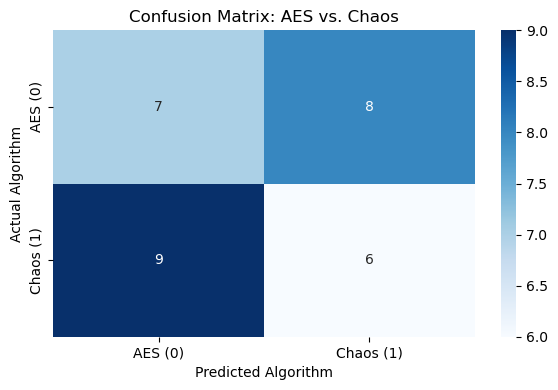


Feature Importances:
Feature  Importance
 Corr_D    0.202879
Entropy    0.187469
 UACI_%    0.167334
 Corr_V    0.167141
 Corr_H    0.165536
 NPCR_%    0.109641


C:\Users\SANJANA\AppData\Local\Temp\ipykernel_18900\2022487236.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


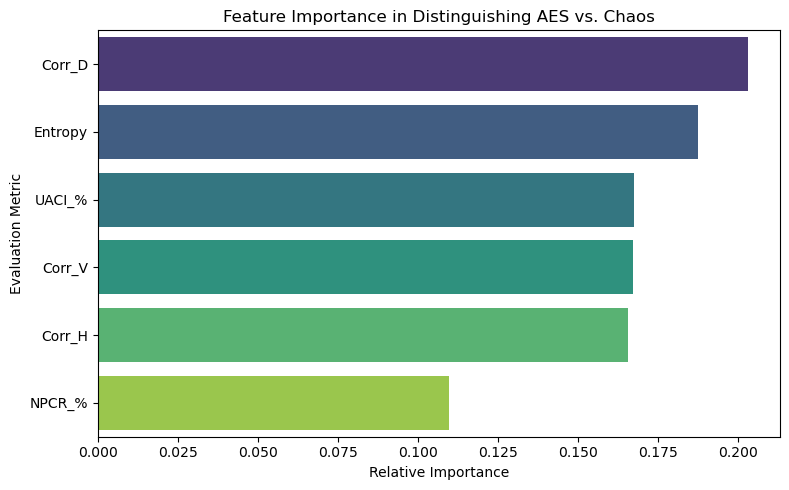

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Load the Data ---
FILE_PATH = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\Book512_512.xlsx"

try:
    # CHANGE THIS LINE: Use read_excel instead of read_csv
    df = pd.read_excel(FILE_PATH)
except FileNotFoundError:
    print(f"Error: Could not find {FILE_PATH}. Please check the file path.")
    exit()

# Drop any potential empty rows
df = df.dropna()

# --- 2. Prepare Data for ML ---
# Define the 6 evaluation metrics as our features
features = ['Entropy', 'Corr_H', 'Corr_V', 'Corr_D', 'NPCR_%', 'UACI_%']

# Check if all required features exist in the dataframe
missing_cols = [col for col in features + ['label'] if col not in df.columns]
if missing_cols:
    print(f"Error: Missing columns in dataset: {missing_cols}")
    exit()

X = df[features]
y = df['label'] # 0 for AES, 1 for Chaos

# Split into 80% training and 20% testing
# stratify=y ensures the train/test split maintains the same proportion of AES and Chaos images
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- 3. Train the Random Forest Model ---
# n_estimators=100 means we are building a forest of 100 decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# --- 4. Evaluate the Model ---
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("===========================================")
print(f"Classification Accuracy: {accuracy * 100:.2f}%")
print("===========================================\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['AES (0)', 'Chaos (1)']))

# --- 5. Visualize Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['AES (0)', 'Chaos (1)'], 
            yticklabels=['AES (0)', 'Chaos (1)'])
plt.title("Confusion Matrix: AES vs. Chaos")
plt.ylabel('Actual Algorithm')
plt.xlabel('Predicted Algorithm')
plt.tight_layout()
plt.show()

# --- 6. Plot Feature Importance ---
# Extract how much each metric contributed to the model's decisions
importances = rf_model.feature_importances_
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})

# Sort from most important to least important
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("\nFeature Importances:")
print(importance_df.to_string(index=False))

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title("Feature Importance in Distinguishing AES vs. Chaos")
plt.xlabel("Relative Importance")
plt.ylabel("Evaluation Metric")
plt.tight_layout()
plt.show()

Classification Accuracy: 59.09%

Classification Report:
              precision    recall  f1-score   support

     AES (0)       0.62      0.45      0.53        11
   Chaos (1)       0.57      0.73      0.64        11

    accuracy                           0.59        22
   macro avg       0.60      0.59      0.58        22
weighted avg       0.60      0.59      0.58        22



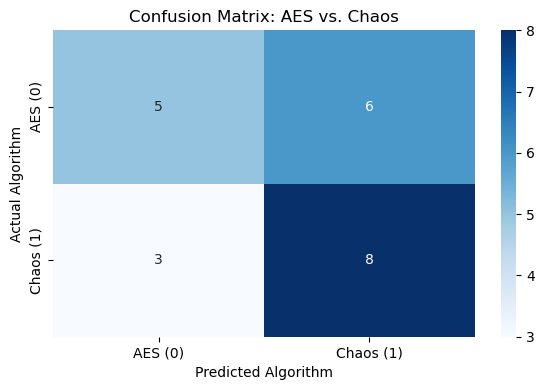


Feature Importances:
Feature  Importance
 Corr_H    0.230371
 Corr_V    0.170065
Entropy    0.167344
 NPCR_%    0.151343
 Corr_D    0.143769
 UACI_%    0.137107


C:\Users\SANJANA\AppData\Local\Temp\ipykernel_2280\422599866.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


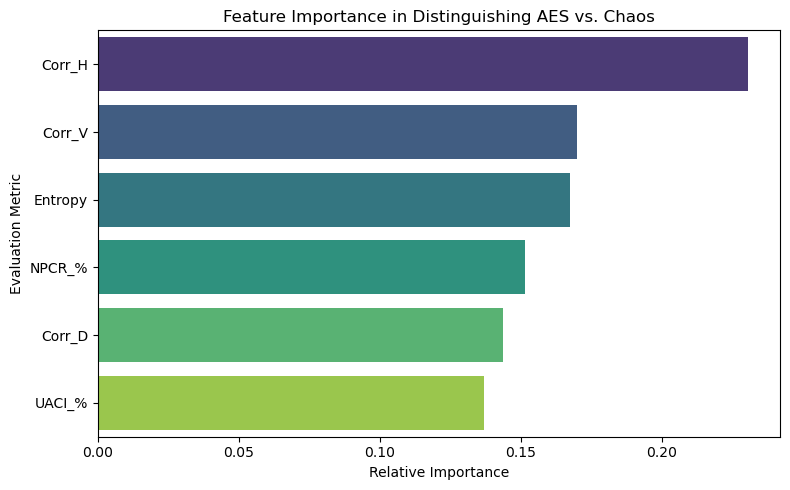

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Load the Data ---
FILE_PATH = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\Book1024_1024.xlsx"

try:
    # CHANGE THIS LINE: Use read_excel instead of read_csv
    df = pd.read_excel(FILE_PATH)
except FileNotFoundError:
    print(f"Error: Could not find {FILE_PATH}. Please check the file path.")
    exit()

# Drop any potential empty rows
df = df.dropna()

# --- 2. Prepare Data for ML ---
# Define the 6 evaluation metrics as our features
features = ['Entropy', 'Corr_H', 'Corr_V', 'Corr_D', 'NPCR_%', 'UACI_%']

# Check if all required features exist in the dataframe
missing_cols = [col for col in features + ['label'] if col not in df.columns]
if missing_cols:
    print(f"Error: Missing columns in dataset: {missing_cols}")
    exit()

X = df[features]
y = df['label'] # 0 for AES, 1 for Chaos

# Split into 80% training and 20% testing
# stratify=y ensures the train/test split maintains the same proportion of AES and Chaos images
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- 3. Train the Random Forest Model ---
# n_estimators=100 means we are building a forest of 100 decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# --- 4. Evaluate the Model ---
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("===========================================")
print(f"Classification Accuracy: {accuracy * 100:.2f}%")
print("===========================================\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['AES (0)', 'Chaos (1)']))

# --- 5. Visualize Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['AES (0)', 'Chaos (1)'], 
            yticklabels=['AES (0)', 'Chaos (1)'])
plt.title("Confusion Matrix: AES vs. Chaos")
plt.ylabel('Actual Algorithm')
plt.xlabel('Predicted Algorithm')
plt.tight_layout()
plt.show()

# --- 6. Plot Feature Importance ---
# Extract how much each metric contributed to the model's decisions
importances = rf_model.feature_importances_
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})

# Sort from most important to least important
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("\nFeature Importances:")
print(importance_df.to_string(index=False))

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title("Feature Importance in Distinguishing AES vs. Chaos")
plt.xlabel("Relative Importance")
plt.ylabel("Evaluation Metric")
plt.tight_layout()
plt.show()

Best params: {'svm__C': 10, 'svm__gamma': 0.01}
Confusion matrix:
 [[6 5]
 [4 7]]
              precision    recall  f1-score   support

      AES(0)       0.60      0.55      0.57        11
    Chaos(1)       0.58      0.64      0.61        11

    accuracy                           0.59        22
   macro avg       0.59      0.59      0.59        22
weighted avg       0.59      0.59      0.59        22

ROC-AUC: 0.5619834710743802

Feature Importances:
Feature  Importance
 Corr_H    0.230371
 Corr_V    0.170065
Entropy    0.167344
 NPCR_%    0.151343
 Corr_D    0.143769
 UACI_%    0.137107


C:\Users\SANJANA\AppData\Local\Temp\ipykernel_2280\240921662.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


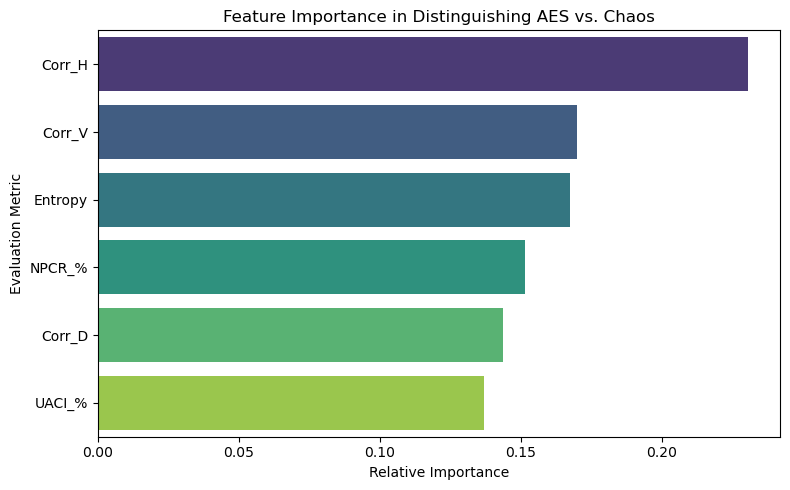

Accuracy: 0.5909090909090909
Accuracy %: 59.09090909090909


In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

df = pd.read_excel("C:\\Class Projects\\Important\\NTCC_Final_Semester\\JNU intership\\Book1024_1024.xlsx")

X = df[["Entropy","Corr_H","Corr_V","Corr_D","NPCR_%","UACI_%"]]
y = df["label"]  # AES=0, Chaos=1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", probability=True))
])

param_grid = {
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", 0.01, 0.1, 1]
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring="f1", n_jobs=-1)
grid.fit(X_train, y_train)

best = grid.best_estimator_
y_pred = best.predict(X_test)
y_prob = best.predict_proba(X_test)[:, 1]

print("Best params:", grid.best_params_)
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["AES(0)", "Chaos(1)"]))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
# Extract how much each metric contributed to the model's decisions
importances = rf_model.feature_importances_
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})

# Sort from most important to least important
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("\nFeature Importances:")
print(importance_df.to_string(index=False))

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title("Feature Importance in Distinguishing AES vs. Chaos")
plt.xlabel("Relative Importance")
plt.ylabel("Evaluation Metric")
plt.tight_layout()
plt.show()
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
print("Accuracy %:", acc*100)

In [9]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.inspection import permutation_importance

# Load
df = pd.read_excel("C:\\Class Projects\\Important\\NTCC_Final_Semester\\JNU intership\\Book1024_1024.xlsx")

feature_cols = ["Entropy","Corr_H","Corr_V","Corr_D","NPCR_%","UACI_%"]
X = df[feature_cols]
y = df["label"]   # AES=0, Chaos=1

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Best SVM (RBF) via tuning
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", probability=True))
])

param_grid = {
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", 0.01, 0.1, 1]
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring="roc_auc", n_jobs=-1)
grid.fit(X_train, y_train)

best = grid.best_estimator_

# Evaluate
proba = best.predict_proba(X_test)[:, 1]
pred = best.predict(X_test)
print("Test ROC-AUC:", roc_auc_score(y_test, proba))
print(classification_report(y_test, pred, target_names=["AES(0)", "Chaos(1)"]))

# Permutation importance on test set (using ROC-AUC)
perm = permutation_importance(
    best, X_test, y_test,
    scoring="roc_auc",
    n_repeats=50,
    random_state=42
)

imp = pd.DataFrame({
    "feature": feature_cols,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print("\nPermutation importance (higher = more important):")
print(imp.to_string(index=False))

Test ROC-AUC: 0.42148760330578516
              precision    recall  f1-score   support

      AES(0)       0.60      0.55      0.57        11
    Chaos(1)       0.58      0.64      0.61        11

    accuracy                           0.59        22
   macro avg       0.59      0.59      0.59        22
weighted avg       0.59      0.59      0.59        22


Permutation importance (higher = more important):
feature  importance_mean  importance_std
 Corr_H         0.056364        0.097362
Entropy         0.055372        0.034642
 NPCR_%         0.029091        0.031804
 Corr_D         0.022479        0.008907
 Corr_V         0.021157        0.009939
 UACI_%         0.014380        0.017002


Best params: {'svm__C': 1, 'svm__gamma': 1}
Confusion matrix:
 [[ 2 13]
 [ 6  9]]
              precision    recall  f1-score   support

      AES(0)       0.25      0.13      0.17        15
    Chaos(1)       0.41      0.60      0.49        15

    accuracy                           0.37        30
   macro avg       0.33      0.37      0.33        30
weighted avg       0.33      0.37      0.33        30

ROC-AUC: 0.3155555555555556

Feature Importances:
Feature  Importance
 Corr_D    0.202879
Entropy    0.187469
 UACI_%    0.167334
 Corr_V    0.167141
 Corr_H    0.165536
 NPCR_%    0.109641


C:\Users\SANJANA\AppData\Local\Temp\ipykernel_18900\3754910608.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


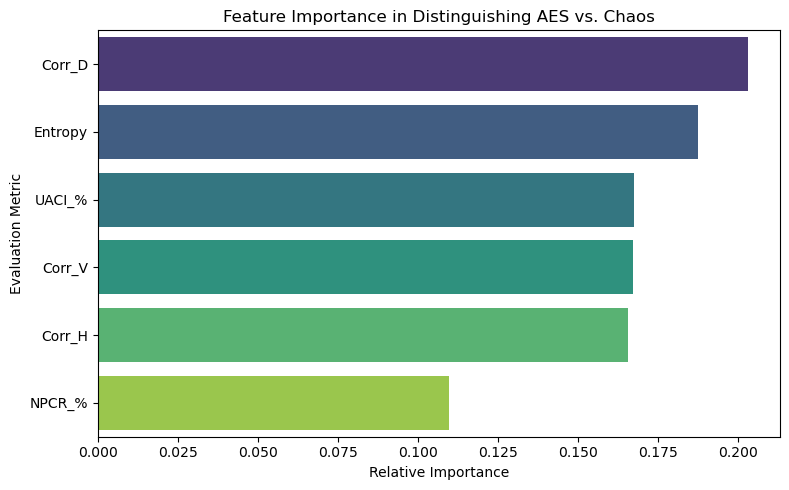

Accuracy: 0.36666666666666664
Accuracy %: 36.666666666666664


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

df = pd.read_excel("C:\\Class Projects\\Important\\NTCC_Final_Semester\\JNU intership\\Book512_512.xlsx")

X = df[["Entropy","Corr_H","Corr_V","Corr_D","NPCR_%","UACI_%"]]
y = df["label"]  # AES=0, Chaos=1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", probability=True))
])

param_grid = {
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", 0.01, 0.1, 1]
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring="f1", n_jobs=-1)
grid.fit(X_train, y_train)

best = grid.best_estimator_
y_pred = best.predict(X_test)
y_prob = best.predict_proba(X_test)[:, 1]

print("Best params:", grid.best_params_)
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["AES(0)", "Chaos(1)"]))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
# Extract how much each metric contributed to the model's decisions
importances = rf_model.feature_importances_
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})

# Sort from most important to least important
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("\nFeature Importances:")
print(importance_df.to_string(index=False))

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title("Feature Importance in Distinguishing AES vs. Chaos")
plt.xlabel("Relative Importance")
plt.ylabel("Evaluation Metric")
plt.tight_layout()
plt.show()
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
print("Accuracy %:", acc*100)

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.inspection import permutation_importance

# Load
df = pd.read_excel("C:\\Class Projects\\Important\\NTCC_Final_Semester\\JNU intership\\Book512_512.xlsx")

feature_cols = ["Entropy","Corr_H","Corr_V","Corr_D","NPCR_%","UACI_%"]
X = df[feature_cols]
y = df["label"]   # AES=0, Chaos=1

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Best SVM (RBF) via tuning
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", probability=True))
])
param_grid = {
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", 0.01, 0.1, 1]
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring="roc_auc", n_jobs=-1)
grid.fit(X_train, y_train)

best = grid.best_estimator_

# Evaluate
proba = best.predict_proba(X_test)[:, 1]
pred = best.predict(X_test)
print("Test ROC-AUC:", roc_auc_score(y_test, proba))
print(classification_report(y_test, pred, target_names=["AES(0)", "Chaos(1)"]))

# Permutation importance on test set (using ROC-AUC)
perm = permutation_importance(
    best, X_test, y_test,
    scoring="roc_auc",
    n_repeats=50,
    random_state=42
)

imp = pd.DataFrame({
    "feature": feature_cols,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print("\nPermutation importance (higher = more important):")
print(imp.to_string(index=False))

Test ROC-AUC: 0.64
              precision    recall  f1-score   support

      AES(0)       0.25      0.13      0.17        15
    Chaos(1)       0.41      0.60      0.49        15

    accuracy                           0.37        30
   macro avg       0.33      0.37      0.33        30
weighted avg       0.33      0.37      0.33        30


Permutation importance (higher = more important):
feature  importance_mean  importance_std
 Corr_V        -0.024444        0.066401
 UACI_%        -0.067733        0.045694
Entropy        -0.099822        0.073661
 Corr_H        -0.108889        0.064994
 Corr_D        -0.118311        0.056798
 NPCR_%        -0.120089        0.074939
